## <h1 style="color: aqua;">Part 3 of the Project! Putting it all together!</h1>


##### Welcome to the last notebook, where we will combine all cleaned data into one SQLite table and analyze the data. Before we can build our database out, we need to have a defined relationship diagram that shows how are various tables and information will be related. As with every notebook, I start off by laying out the Entity Relationship Diagram (ERD) to lay out how the tables should be created.  As you can see, we have a "main" table which our primary table concerning tornado data. We also have a supplemental table, the FEMA declarations table to have support our theory. Lastly, we have a third table to help bridge the connection between the two tables. This is our lookup table and contains geographical information.


![Tornado ERD](../Assets/Tornado_ERD.jpeg)

In [358]:
# Before any coding begins, we need to import all needed libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sqlite3
import geopandas as ge
import seaborn as sns
import geodatasets
from matplotlib.patches import Patch

os.makedirs('../Data/Tornado_SQL_database', exist_ok=True)
print(os.path.exists('../Data/Tornado_SQL_database'))

# Connect to (or create) the database using the conn variable 
conn = sqlite3.connect('../Data/Tornado_SQL_database/tornado_alley.db') # The cursor command lets us run commands to the connection crated above. You can't run SQL directly on the connection, hence the use of cursor.
cursor = conn.cursor()

# Creating tables // cursor.executescript() is the cursor performing the command to create multiple SQL statements at once.
cursor.executescript(""" 
    CREATE TABLE IF NOT EXISTS state_regions (
        state                  TEXT PRIMARY KEY,
        region_name            TEXT NOT NULL,
        is_eastern_shift_state INTEGER NOT NULL DEFAULT 0
    );

    CREATE TABLE IF NOT EXISTS fema_declarations (
        disaster_number  INTEGER PRIMARY KEY,
        state            TEXT NOT NULL,
        year             INTEGER NOT NULL,
        declaration_type TEXT NOT NULL,
        ia_declared      INTEGER NOT NULL DEFAULT 0,
        ih_declared      INTEGER NOT NULL DEFAULT 0,
        incident_type    TEXT NOT NULL
    );

    CREATE TABLE IF NOT EXISTS tornado_events (
        event_id          INTEGER PRIMARY KEY,
        state             TEXT NOT NULL,
        tor_f_scale       TEXT,
        tor_length        REAL,
        tor_width         REAL,
        fatalities        INTEGER NOT NULL,
        injuries          INTEGER NOT NULL,
        year              INTEGER NOT NULL
    );
""")

conn.commit() # SQL does not saves changes until they are commited.
print("Tables created successfully.")

True
Tables created successfully.


In [359]:
# Load cleaned data from CSVs
tornado_df = pd.read_csv('../Data/Cleaned_Tornado_Data/tornado_all_years_cleaned.csv')
FEMA_df = pd.read_csv('../Data/Cleaned_FEMA_Data/FEMA_data_cleaned.csv')
state_regions_df = pd.read_csv('../Data/Cleaned_Tornado_Data/eastern_state_notation.csv')

# Connect to database
conn = sqlite3.connect('../Data/Tornado_SQL_database/tornado_alley.db')

# Load into SQL tables
state_regions_df.to_sql('state_regions', conn, if_exists='replace', index=False)
tornado_df.to_sql('tornado_events', conn, if_exists='replace', index=False)
FEMA_df.to_sql('fema_declarations', conn, if_exists='replace', index=False)

conn.commit()
print("Data loaded successfully.")

Data loaded successfully.


## <h2 style="color: aqua;">Main Question: "Has tornado alley shifted eastward?"</h2>

Now that we have all of the data loaded, we need to circle back to the main purpose of this project. Analyzing if the "tornado alley" is shifting eastward. The best way to answer this question is to look at the numerical data and compare. The most obvious route is to look at total tornadoes over each decade in the three state categories. Based on the data below, we could say that, yes, it appears that emerging states now have more tornadoes than they did decades ago. But it is important to note that the original states still see a massive amount of tornadoes. Therefore it is less of a "shift" and more of a "growth."

In [360]:
# Selecting year and region name AS tornado count from tornado events, joining the state table on state column, grouping by year.
pd.read_sql("""
    SELECT t.year, s.region_name, COUNT(*) as tornado_count 
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    GROUP BY t.year, s.region_name
    ORDER BY t.year
""", conn)

,year,region_name,tornado_count
0,2004,Emerging,617
1,2004,Other,550
2,2004,Traditional,780
3,2014,Emerging,412
4,2014,Other,265
5,2014,Traditional,387
6,2024,Emerging,911
7,2024,Other,412
8,2024,Traditional,806


## <h2 style="color: aqua;">Follow up question: Are tornadoes getting stronger in recent decades compared to previous decades?</h2>

##### We can deduce that again, yes, tornadoes in 2024 seem to be stronger in terms of width and length. This is not using the EF Scale we made earlier, this is looking at the raw data over the length of the tornado (how long it was on the ground) and how wide it was. Note: Length and width are measured in terms of miles.

In [361]:
# Selecting year and region name from tornado events, joining state regions table on state columns.
pd.read_sql("""
    SELECT t.year, s.region_name, 
           AVG(t.tor_length) as avg_length,
           AVG(t.tor_width) as avg_width
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    GROUP BY t.year, s.region_name
    ORDER BY t.year
""", conn)

,year,region_name,avg_length,avg_width
0,2004,Emerging,2.865478,0.058705
1,2004,Other,3.044727,0.044460
2,2004,Traditional,1.760641,0.062445
3,2014,Emerging,3.681262,0.120016
4,2014,Other,2.064000,0.066344
5,2014,Traditional,2.664160,0.103387
6,2024,Emerging,4.008332,0.138748
7,2024,Other,3.700097,0.088984
8,2024,Traditional,3.400918,0.116725


## <h2 style="color: aqua;">Follow up question: Are there more FEMA declarations in recent decades compared to years past?</h2>

##### This is where the data begins to tell another story, but it is important to keep in mind what the data for FEMA includes. The FEMA dataset not only included tornadoes, but it also included severe storms. Some storms may be severe, but never produce a tornado. A plethora of straight line wind damage, flooding, or other damage from a severe storm might cause a FEMA declaration, but not a tornado. This is most likely why the declarations in 2004 were quite high compared to other decades. But the the overall growth of tornadoes still seems to be present from 2014 to 2024.

In [362]:
pd.read_sql("""
    SELECT f.year, s.region_name, COUNT(*) as declaration_count
    FROM fema_declarations f
    JOIN state_regions s ON f.state = s.state
    GROUP BY f.year, s.region_name
    ORDER BY f.year
""", conn)

,year,region_name,declaration_count
0,2004,Emerging,442
1,2004,Other,428
2,2004,Traditional,216
3,2014,Emerging,104
4,2014,Other,51
5,2014,Traditional,83
6,2024,Emerging,109
7,2024,Other,195
8,2024,Traditional,240


### <h2 style="color: lime;">Visual Evidence</h2>

While raw data can give clear evidence, it may not as easy to digest as a diagram outlining this information. At first, I attempted to place this information on a heat map to show tornado counts have grown per state.

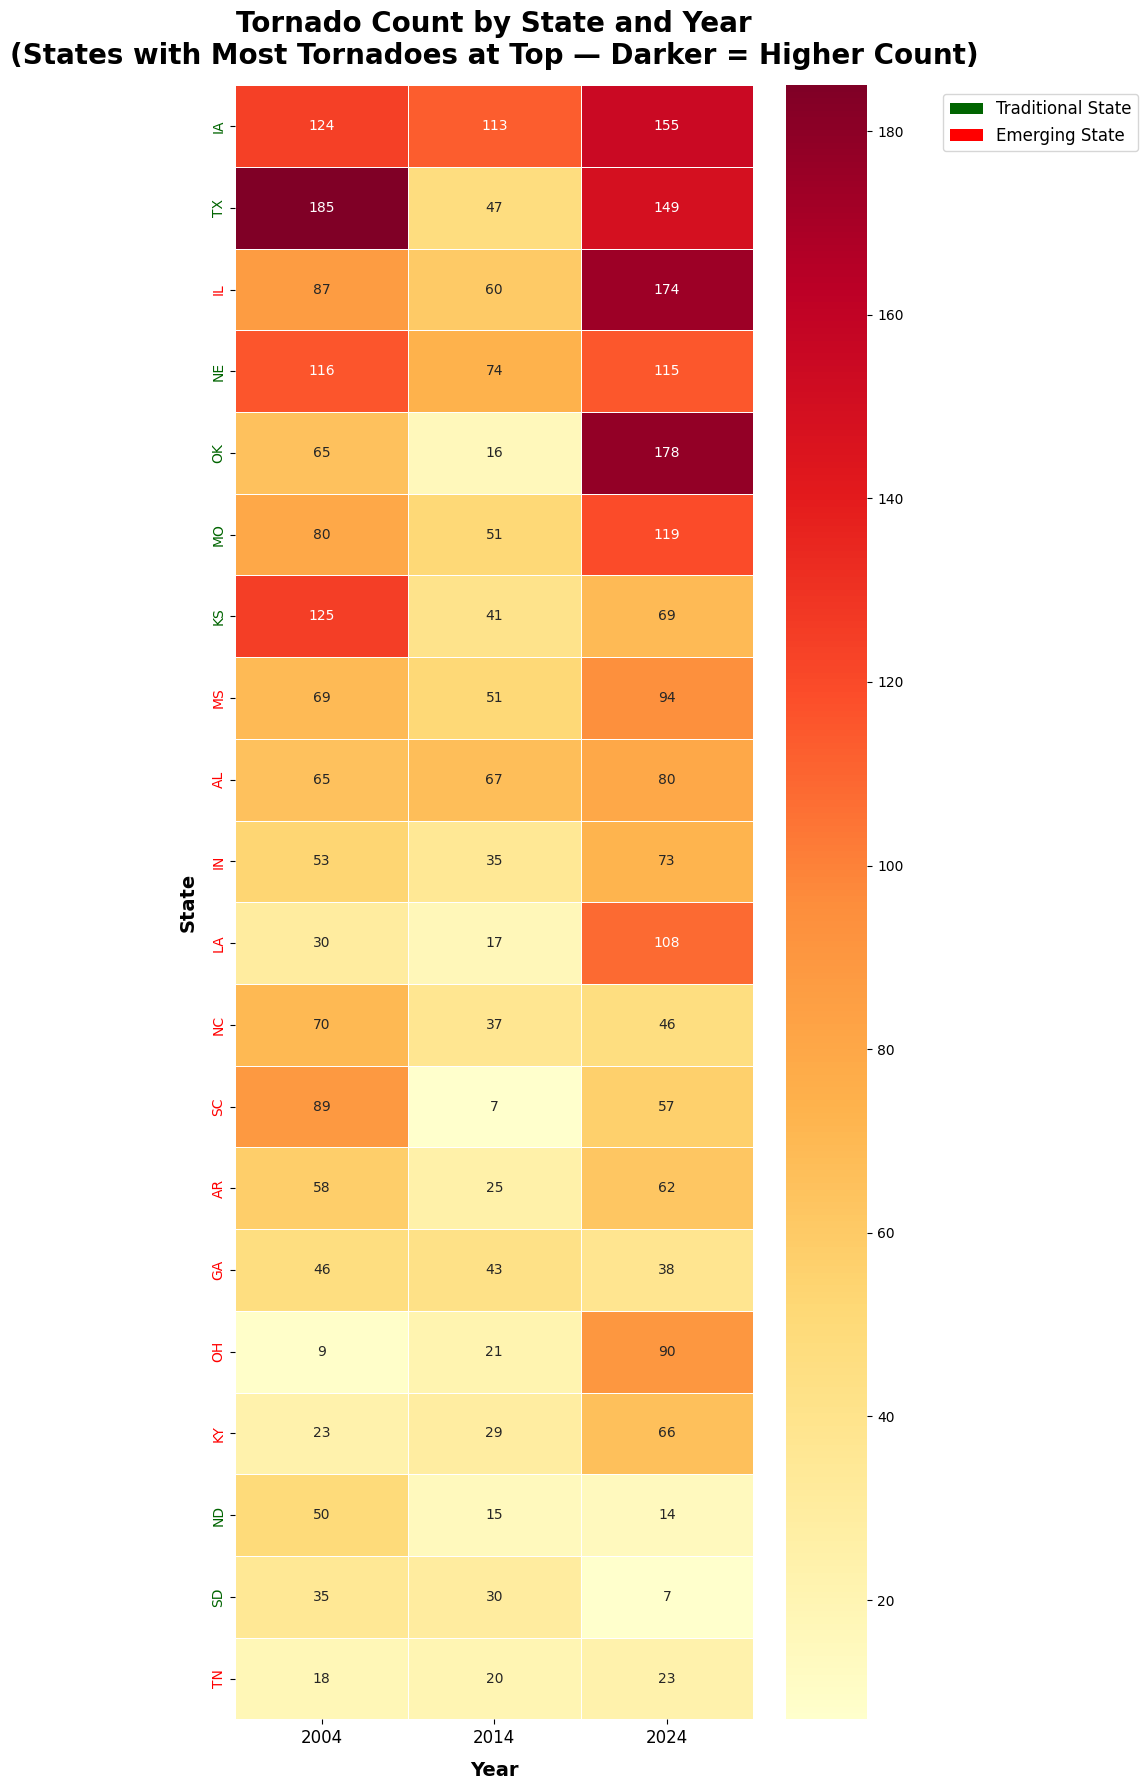

In [363]:
# Query tornado count by state and year
heatmap_df = pd.read_sql("""
    SELECT t.state, t.year, COUNT(*) as tornado_count
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    WHERE s.region_name IN ('Traditional', 'Emerging')
    GROUP BY t.state, t.year
    ORDER BY t.year
""", conn)

# Pivot for heatmap format
heatmap_pivot = heatmap_df.pivot(index='state', columns='year', values='tornado_count').fillna(0)

# Sort by total tornado count so most active states are at the top
heatmap_pivot = heatmap_pivot.loc[heatmap_pivot.sum(axis=1).sort_values(ascending=False).index]

# Create region lookup
region_lookup = pd.read_sql("SELECT state, region_name FROM state_regions", conn)
region_dict = dict(zip(region_lookup['state'], region_lookup['region_name']))

fig, ax = plt.subplots(figsize=(10, 18))
sns.heatmap(
    heatmap_pivot,
    cmap='YlOrRd',
    linewidths=0.5,
    annot=True,
    fmt='.0f',
    ax=ax
)

# Color y-axis labels by region
for label in ax.get_yticklabels():
    state = label.get_text()
    if region_dict.get(state) == 'Traditional':
        label.set_color('darkgreen')
    elif region_dict.get(state) == 'Emerging':
        label.set_color('red')

# Legend
legend_elements = [Patch(facecolor='darkgreen', label='Traditional State'),
                   Patch(facecolor='red', label='Emerging State')]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.35, 1), loc='upper left', fontsize=12)

ax.set_title('Tornado Count by State and Year\n(States with Most Tornadoes at Top — Darker = Higher Count)', fontsize=20, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('State', fontsize=14, fontweight='bold', labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('../Graphs/heatmap_tornado_count.png', bbox_inches='tight', dpi=300)
plt.show()

##### The above heat map is sufficient if we want to look at a numerical value of tornadoes. For example, we can see the IL has an extreme increase in tornadoes. This did not really achieve the goal I wanted, as this heatmap was quite large and cumbersome to look at. Therefore, I opted to use the GeoPandas library to plot the data over the United States. I also decided on doing one map per decade, so it is easier to decipher growth or reduction of tornadoes. Note: I did end up dropping Hawaii and Alaska to make the map easier to view, as those states are not relevant for our analysis.

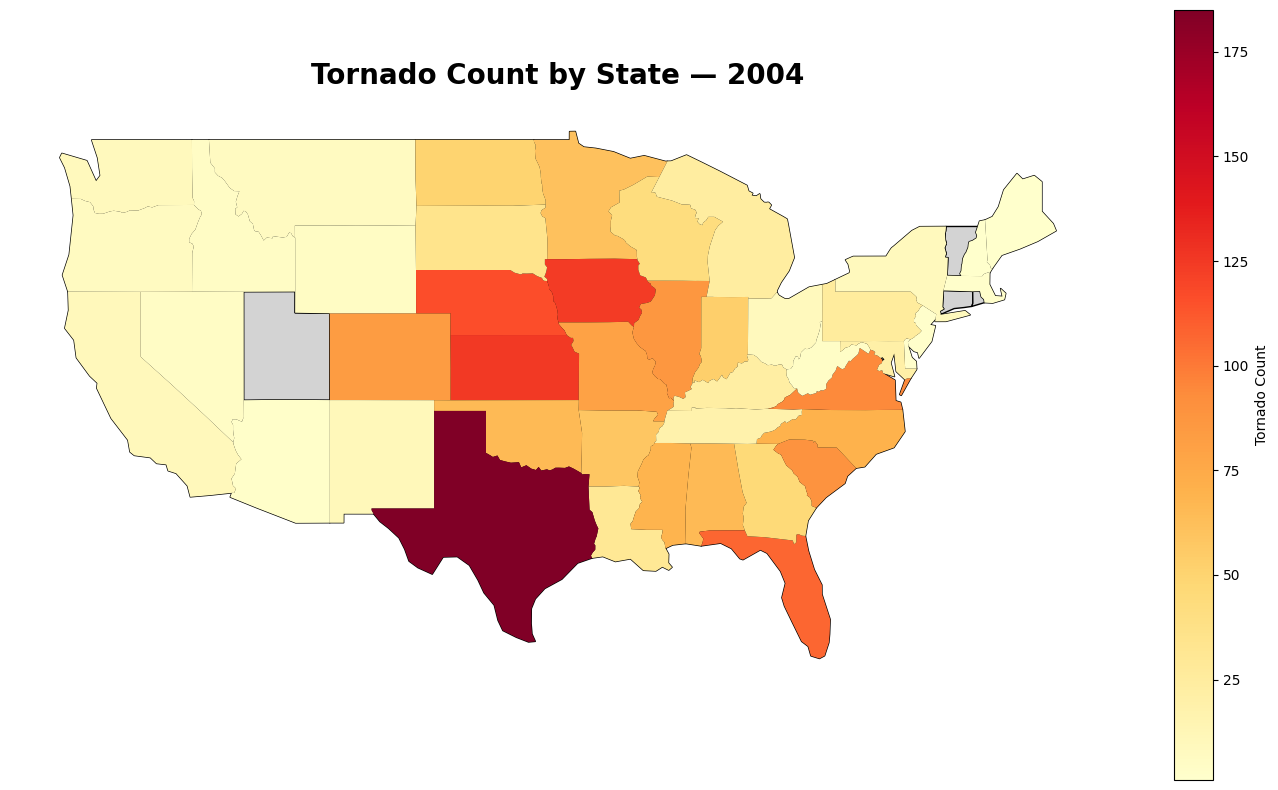

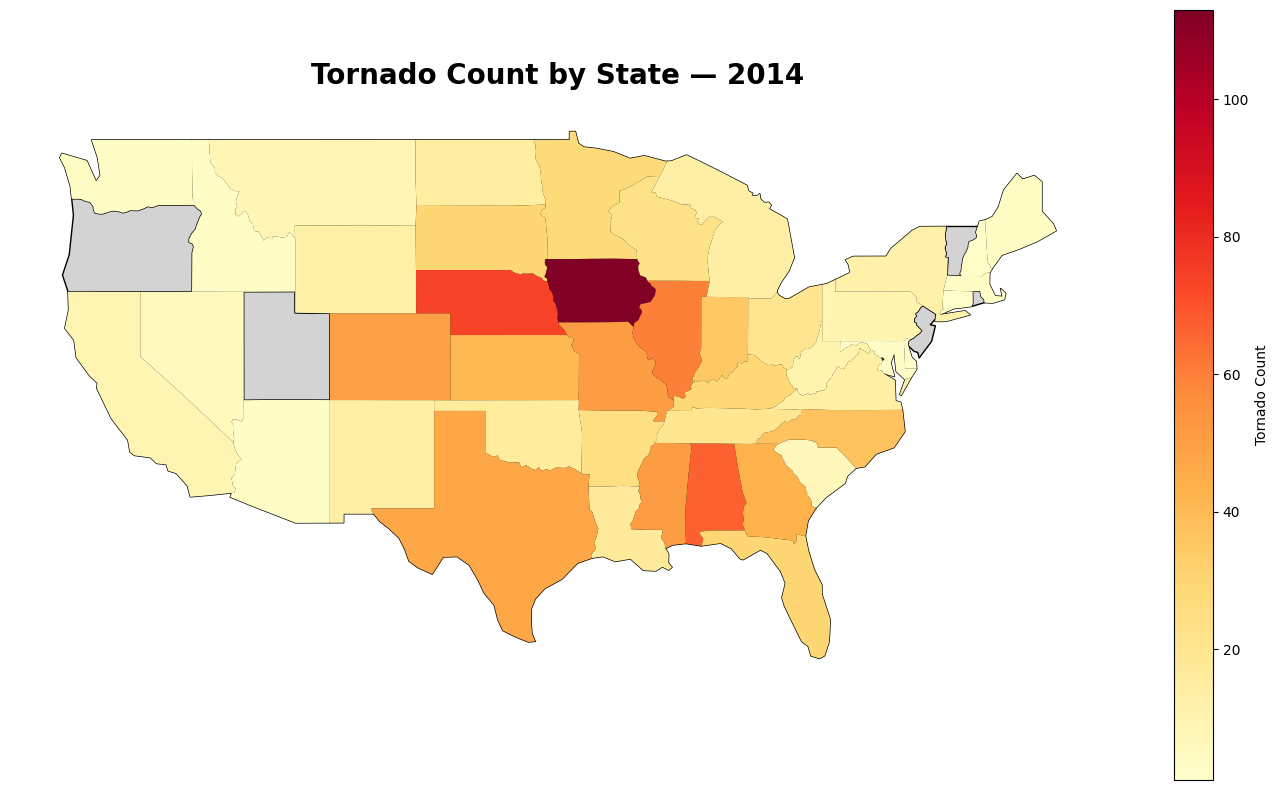

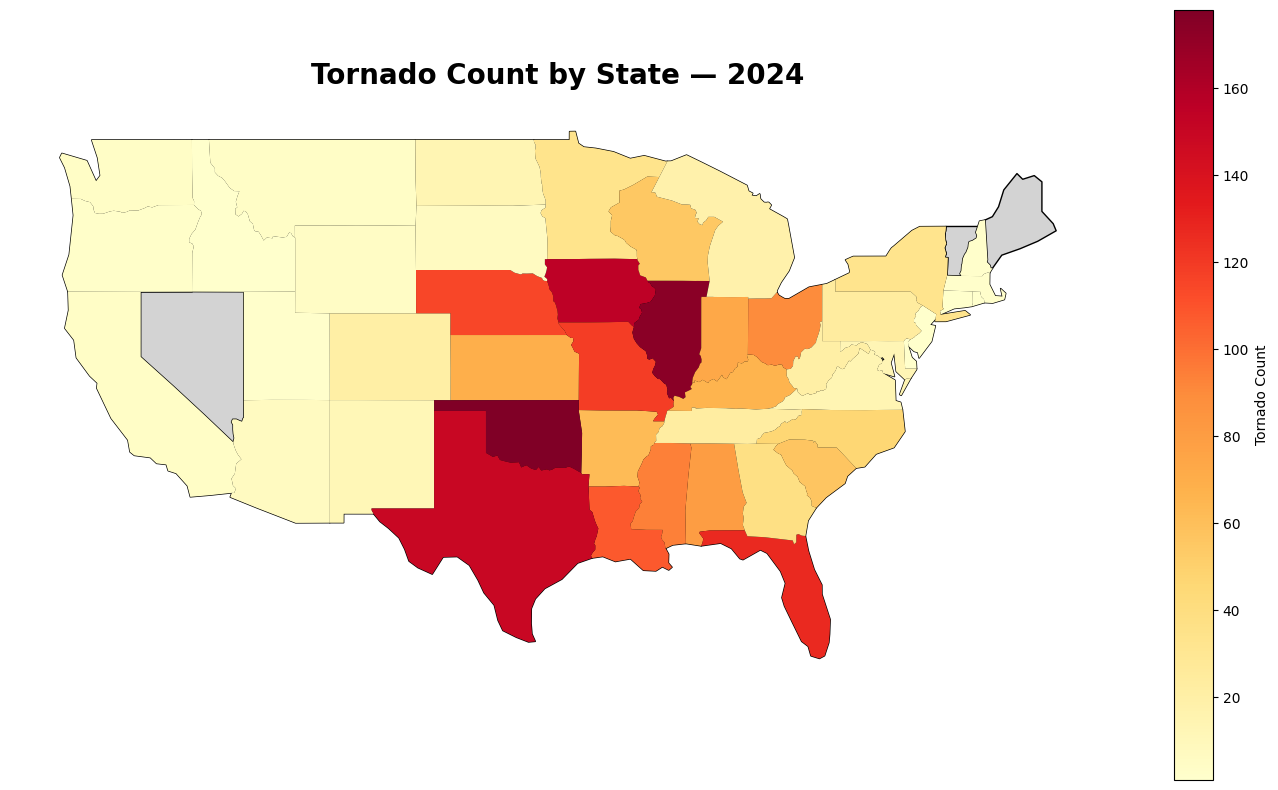

In [364]:
# Query tornado counts by state. We SELECT FROM tornado events table, and join the STATE table.
map_df = pd.read_sql("""
    SELECT t.state, t.year, COUNT(*) as tornado_count, 
           AVG(t.tor_length) as avg_length,
           s.region_name
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    GROUP BY t.state, t.year
""", conn)

# Need to convert abbreviations back to full names to match GeoJSON. 
state_names = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming'
}

map_df['state_name'] = map_df['state'].map(state_names)

# Merge with GeoDataFrame 
merged = continental.merge(map_df, left_on='name', right_on='state_name', how='left')

# Plot one year at a time using a for loop.
for year in [2004, 2014, 2024]:
    year_data = merged[merged['year'] == year]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    continental.plot(ax=ax, color='lightgrey', edgecolor='black')
    year_data.plot(
        column='tornado_count',
        ax=ax,
        cmap='YlOrRd',
        legend=True,
        legend_kwds={'label': 'Tornado Count'}
    )
    plt.title(f'Tornado Count by State — {year}', fontsize=20, fontweight='bold', pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'../Graphs/tornado_map_{year}.png', bbox_inches='tight', dpi=300)
    plt.show()

This is more in line with my original thoughts shared above. Tornado alley isn't "shifting eastward", it is branching out and growing into eastern states. Our "traditional" states still show a high coloration of dark reds, while "emerging states" seem to get darker as the decades pass by.